# MCP ACTUARIAL — Modelo de Frecuencia de Siniestros en Seguros de Automóviles

## Sección 0: Metadata del Modelo

| Campo | Valor |
|---|---|
| **Nombre del modelo** | GLM Poisson — Frecuencia de Siniestros (Automóviles) |
| **Versión** | 2.0 (refactor post-retroalimentación Abril 2026) |
| **Fecha** | Abril 2026 |
| **Autor** | Marco Barragán |
| **Dataset** | French Motor TPL (freMTPL2freq) — 677,991 pólizas |
| **Propósito** | Modelar la frecuencia esperada de siniestros por póliza-año para la tarificación actuarial |
| **Usuario objetivo** | Área técnica actuarial / comité de modelos / auditoría interna |
| **Marco de referencia** | ASOP 56 (Modeling), SR 11-7 (Model Risk Management) |
| **Distribución** | Poisson con función de enlace log (comparada formalmente con quasi-Poisson y Binomial Negativa) |
| **Variable respuesta** | ClaimNb (número de siniestros) |
| **Offset** | log(Exposure) — tiempo de exposición en años |

---

### Changelog v2 (correcciones aplicadas según retroalimentación del asesor, Abril 2026)

1. **Texto del Gini corregido** (0.244 → 0.2835) — el código es la fuente de verdad.
2. **Gráfica de residuos de Pearson** — escala `ylim(-3, 15)` + bandas ±2 SE; ahora la región negativa (96% de pólizas con ClaimNb=0) es visible.
3. **SHAP** — se cambió `feature_perturbation='correlation_dependent'` por `shap.maskers.Independent` (evita overflow/NaN cuando las dummies de OHE son colineales).
4. **BIC** — se reporta `bic_llf` (basado en log-verosimilitud, estándar actuarial) en lugar de `bic` legacy (basado en devianza).
5. **Tabla de inputs (Sección 9.6)** — se agregan filas para `VehBrand` y `Area` como variables **excluidas**, con su justificación técnica.
6. **Nota técnica sobre SHAP + OHE** — se agregó en la celda Markdown de la Sección 7.
7. **Análisis de sesgo por decil** (nueva sub-sección) — columna `sesgo_pct` y discusión del patrón decil 6–8 vs. decil 9.
8. **Comparación formal de modelos** (nueva celda) — Poisson vs. quasi-Poisson vs. Binomial Negativa con AIC, devianza y Mean Poisson Deviance fuera de muestra.
9. **Interpretación actuarial del bee-swarm plot** (nueva celda) — párrafo por cada variable top-5 en términos de negocio.

---

### Alcance del modelo
Este modelo estima la frecuencia de siniestros de responsabilidad civil de automóviles para una cartera francesa, utilizando características del conductor, del vehículo y del entorno geográfico. El modelo **no** predice la severidad de los siniestros ni el costo total de los mismos.

### Resumen de la estructura MCP

| Sección | Contenido |
|---|---|
| 0 — Metadata | Identificación, propósito y contexto del modelo |
| 1 — Carga y EDA | Exploración descriptiva y actuarial de los datos |
| 2 — Preparación | Transformaciones, agrupaciones y codificación |
| 3 — Supuestos Formales | Distribución, función de enlace, independencia |
| 4 — Especificación Matemática | Log-verosimilitud, IRLS, offset |
| 5 — Ajuste del Modelo | GLM con intercepto, sobredispersión, comparación Poisson/qP/NB |
| 6 — Validación Cuantitativa | Deviance, AIC, BIC (llf), tabla deciles, sesgo por decil, Lorenz, Gini, MPD |
| 7 — Explicabilidad | Relatividades + SHAP values (maskers.Independent) + interpretación actuarial |
| 8 — Comparación MCP vs. Tradicional | Tabla 10 dimensiones |
| 9 — Gobernanza y Límites | Variables incluidas/excluidas, ASOP 56, SR 11-7 |


In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# 1. Carga del dataset

Se carga el dataset French Motor TPL, el cual contiene información de pólizas de seguro, incluyendo el número de siniestros, la exposición y diversas características del conductor, del vehículo y del entorno.

Este dataset será utilizado para modelar la frecuencia de siniestros mediante un modelo GLM Poisson.

En este paso se verifica que el archivo se cargue correctamente y se revisa su tamaño y estructura general.

In [64]:
df = pd.read_csv("freMTPL2freq.csv")
print("Dimensiones del dataset:")
print(df.shape)

df.head()

Dimensiones del dataset:
(677991, 12)


,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region
0,1.0,0,0.10,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes
1,3.0,0,0.77,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes
2,5.0,0,0.75,6,2,52,50,B12,Diesel,B,54,Picardie
3,10.0,0,0.09,7,0,46,50,B12,Diesel,B,76,Aquitaine
4,11.0,0,0.84,7,0,46,50,B12,Diesel,B,76,Aquitaine


# 2. Exploración inicial de los datos

Se revisa la estructura del dataset, incluyendo los tipos de variables y la presencia de valores faltantes.

Este paso permite confirmar que las variables están correctamente definidas y que los datos están completos antes de continuar con el modelado.

In [65]:
# Tipos de variables
print("Tipos de variables:")
print(df.dtypes)

print("\n")

# Valores faltantes
print("Valores faltantes por variable:")
print(df.isnull().sum())

Tipos de variables:
IDpol         float64
ClaimNb         int64
Exposure      float64
VehPower        int64
VehAge          int64
DrivAge         int64
BonusMalus      int64
VehBrand       object
VehGas         object
Area           object
Density         int64
Region         object
dtype: object


Valores faltantes por variable:
IDpol         0
ClaimNb       0
Exposure      0
VehPower      0
VehAge        0
DrivAge       0
BonusMalus    0
VehBrand      0
VehGas        0
Area          0
Density       0
Region        0
dtype: int64


# 2.1 
También se revisa que la variable Exposure tenga valores válidos, ya que esta será utilizada como offset en el modelo GLM y no puede contener valores menores o iguales a cero.

In [66]:
# Verificar valores inválidos en Exposure
print("Número de Exposure <= 0:")
print((df["Exposure"] <= 0).sum())

# Estadísticos básicos
print("\nResumen estadístico:")
df.describe()

Número de Exposure <= 0:
0

Resumen estadístico:


,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,Density
count,6.779910e+05,677991.000000,677991.000000,677991.000000,677991.000000,677991.000000,677991.000000,677991.000000
mean,2.621886e+06,0.039003,0.528743,6.454649,7.044244,45.499092,59.761559,1792.406856
std,1.641776e+06,0.207169,0.364441,2.050914,5.666226,14.137449,15.636713,3958.574057
min,1.000000e+00,0.000000,0.002732,4.000000,0.000000,18.000000,50.000000,1.000000
25%,1.157964e+06,0.000000,0.180000,5.000000,2.000000,34.000000,50.000000,92.000000
50%,2.272157e+06,0.000000,0.490000,6.000000,6.000000,44.000000,50.000000,393.000000
75%,4.046271e+06,0.000000,0.990000,7.000000,11.000000,55.000000,64.000000,1658.000000
max,6.114330e+06,16.000000,2.010000,15.000000,100.000000,100.000000,230.000000,27000.000000


## 3. Preparación de variables

En este paso se preparan las variables necesarias para la construcción del modelo GLM Poisson.

Primero se calcula el logaritmo de la exposición. Esta transformación se utiliza como offset en el modelo, lo que permite modelar la frecuencia de siniestros en lugar del conteo bruto.

El uso del offset es estándar en modelos actuariales de frecuencia, ya que ajusta el modelo según el tiempo de exposición de cada póliza.

In [67]:
import numpy as np

# Crear variable offset
df["log_Exposure"] = np.log(df["Exposure"])

# Verificar resultado
print("Primeras filas de Exposure y log_Exposure:")
print(df[["Exposure", "log_Exposure"]].head())

Primeras filas de Exposure y log_Exposure:
   Exposure  log_Exposure
0      0.10     -2.302585
1      0.77     -0.261365
2      0.75     -0.287682
3      0.09     -2.407946
4      0.84     -0.174353


## 4. Agrupación de variables

En este paso se agrupan algunas variables continuas en rangos. Esto permite capturar mejor el comportamiento del riesgo, ya que la relación entre estas variables y la frecuencia de siniestros no es necesariamente lineal.

Este procedimiento es común en modelos actuariales, ya que facilita la interpretación y mejora la estabilidad del modelo.

In [68]:
# Agrupar edad del conductor
# include_lowest=True garantiza que DrivAge=18 (edad mínima) quede incluido
# y no produzca NaN — el intervalo pasa de (18, 21] a [18, 21]
df["DrivAge_group"] = pd.cut(
    df["DrivAge"],
    bins=[18, 21, 25, 30, 40, 50, 60, 70, 100],
    right=True,
    include_lowest=True
)

# Agrupar edad del vehículo
# include_lowest=True garantiza que VehAge=0 (vehículos nuevos) quede incluido
# y no produzca NaN — corrección necesaria: 57,748 pólizas afectadas
df["VehAge_group"] = pd.cut(
    df["VehAge"],
    bins=[0, 1, 2, 5, 10, 20, 100],
    right=True,
    include_lowest=True
)

# Verificar que no haya NaN
assert df["VehAge_group"].isna().sum() == 0, "VehAge_group tiene NaN"
assert df["DrivAge_group"].isna().sum() == 0, "DrivAge_group tiene NaN"

# Verificar resultado
print("Distribución DrivAge_group:")
print(df["DrivAge_group"].value_counts().sort_index())

print("\nDistribución VehAge_group:")
print(df["VehAge_group"].value_counts().sort_index())


Distribución DrivAge_group:
DrivAge_group
(17.999, 21.0]     11253
(21.0, 25.0]       27640
(25.0, 30.0]       65592
(30.0, 40.0]      170094
(40.0, 50.0]      165179
(50.0, 60.0]      135010
(60.0, 70.0]       63858
(70.0, 100.0]      39365
Name: count, dtype: int64

Distribución VehAge_group:
VehAge_group
(-0.001, 1.0]    129018
(1.0, 2.0]        59122
(2.0, 5.0]       132488
(5.0, 10.0]      171587
(10.0, 20.0]     177455
(20.0, 100.0]      8321
Name: count, dtype: int64


## EDA Actuarial — Frecuencia observada ponderada por exposición

En un modelo actuarial, el EDA descriptivo básico (tipos, nulos, estadísticos) no es suficiente.
El análisis correcto calcula la **frecuencia observada de siniestros por grupo**, ponderada por la exposición.

Esto corresponde al **Input Analysis del MCP**: permite verificar si las variables tienen relación monótona
con el riesgo y justificar su inclusión en el modelo.

**Definición:** Frecuencia observada = Σ(ClaimNb) / Σ(Exposure) por cada grupo.


In [ ]:
def frecuencia_por_grupo(df, variable):
    """Frecuencia observada de siniestros ponderada por exposición."""
    return (
        df.groupby(variable, observed=True)
        .apply(lambda x: x["ClaimNb"].sum() / x["Exposure"].sum(), include_groups=False)
        .reset_index(name="Frecuencia_obs")
    )

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("EDA Actuarial — Frecuencia observada de siniestros ponderada por exposición", fontsize=13)

# ---- DrivAge_group ----
freq_drivage = frecuencia_por_grupo(df, "DrivAge_group")
axes[0, 0].bar(freq_drivage["DrivAge_group"].astype(str), freq_drivage["Frecuencia_obs"], color="steelblue")
axes[0, 0].set_title("Frecuencia por grupo de edad del conductor")
axes[0, 0].set_xlabel("DrivAge_group")
axes[0, 0].set_ylabel("Siniestros / Exposición")
axes[0, 0].tick_params(axis="x", rotation=35)

# ---- VehAge_group ----
freq_vehage = frecuencia_por_grupo(df, "VehAge_group")
axes[0, 1].bar(freq_vehage["VehAge_group"].astype(str), freq_vehage["Frecuencia_obs"], color="coral")
axes[0, 1].set_title("Frecuencia por grupo de edad del vehículo")
axes[0, 1].set_xlabel("VehAge_group")
axes[0, 1].set_ylabel("Siniestros / Exposición")
axes[0, 1].tick_params(axis="x", rotation=35)

# ---- BonusMalus (quintiles) ----
df["BonusMalus_q"] = pd.qcut(df["BonusMalus"], q=5, duplicates="drop")
freq_bonus = frecuencia_por_grupo(df, "BonusMalus_q")
axes[1, 0].bar(freq_bonus["BonusMalus_q"].astype(str), freq_bonus["Frecuencia_obs"], color="mediumseagreen")
axes[1, 0].set_title("Frecuencia por quintil de BonusMalus")
axes[1, 0].set_xlabel("BonusMalus (quintiles)")
axes[1, 0].set_ylabel("Siniestros / Exposición")
axes[1, 0].tick_params(axis="x", rotation=35)

# ---- Region ----
freq_region = frecuencia_por_grupo(df, "Region")
freq_region = freq_region.sort_values("Frecuencia_obs", ascending=False)
axes[1, 1].barh(freq_region["Region"], freq_region["Frecuencia_obs"], color="mediumpurple")
axes[1, 1].set_title("Frecuencia observada por Región")
axes[1, 1].set_xlabel("Siniestros / Exposición")

plt.tight_layout()
plt.show()

print("\nTabla: Frecuencia observada por grupo de edad del conductor:")
print(freq_drivage.to_string(index=False))


## 5. Transformación de la variable Density

Se aplica una transformación logarítmica a la variable Density.

Esta transformación permite reducir la asimetría de la variable y mejorar la estabilidad del modelo GLM.

La transformación logarítmica es común en modelos actuariales cuando las variables presentan distribuciones altamente sesgadas.

In [ ]:
# ============================================================
# TRANSFORMACIÓN LOGARÍTMICA DE DENSITY
# ============================================================

df["log_Density"] = np.log(df["Density"])

# verificar resultado
df[["Density", "log_Density"]].head()

,Density,log_Density
0,1217,7.104144
1,1217,7.104144
2,54,3.988984
3,76,4.330733
4,76,4.330733


In [ ]:
# ============================================================
# A1 — Media muestral de log_Density
# Respalda la cifra x̄_LD declarada en la tesina Cap 3 §3.3
# ============================================================

mean_log_density = df["log_Density"].mean()
print(f"Media muestral de log_Density: {mean_log_density:.4f}")
print(f"Sensibilidad marginal log_Density = β̂ · μ̄ = 0.0748 · 0.039 = {0.0748 * 0.039:.6f}")


Media muestral de log_Density: 5.9818
Sensibilidad marginal log_Density = β̂ · μ̄ = 0.0748 · 0.039 = 0.002917


In [ ]:
# ============================================================
# A3 — Colinealidad entre Area (categórica ordinal A-F) y log_Density
# Respalda la afirmación "colinealidad alta" en Cap 2 §2.3
# y justifica la exclusión de Area en Tabla 3.4
# ============================================================

# 1) log_Density promedio por categoría de Area
print("log_Density promedio por Area (ordenado ascendente):")
area_logdens = df.groupby("Area", observed=True)["log_Density"].mean().sort_values()
print(area_logdens.round(4).to_string())

# 2) Correlación: Area codificada como ordinal (A=1, B=2, ..., F=6)
area_map = {"A": 1, "B": 2, "C": 3, "D": 4, "E": 5, "F": 6}
area_ordinal = df["Area"].map(area_map)

# Correlación de Pearson
corr_pearson = area_ordinal.corr(df["log_Density"])
print(f"\nCorrelación Pearson (Area ordinal ↔ log_Density): {corr_pearson:.4f}")

# Correlación Spearman por robustez
corr_spearman = area_ordinal.corr(df["log_Density"], method="spearman")
print(f"Correlación Spearman (Area ordinal ↔ log_Density): {corr_spearman:.4f}")

# Regla de dedo: |corr| > 0.7 es colinealidad alta
print(f"\nConclusión: |r| = {abs(corr_pearson):.4f} → "
      f"{'colinealidad alta (>0.7)' if abs(corr_pearson) > 0.7 else 'colinealidad moderada/baja'}")


log_Density promedio por Area (ordenado ascendente):
Area
A    3.1839
B    4.2635
C    5.4107
D    6.9102
E    8.3013
F    9.9465

Correlación Pearson (Area ordinal ↔ log_Density): 0.9706
Correlación Spearman (Area ordinal ↔ log_Density): 0.9762

Conclusión: |r| = 0.9706 → colinealidad alta (>0.7)


## 5. Transformación logarítmica de la variable Density

Se aplicó una transformación logarítmica a la variable Density para reducir su asimetría.

La variable original presenta valores muy dispersos, mientras que la versión logarítmica permite una relación más estable con la frecuencia de siniestros.

Esta transformación mejora el comportamiento del modelo GLM y es una práctica común en modelación actuarial.

## 6. Definición de variables para el modelo GLM

Se definen las variables predictoras que serán utilizadas en el modelo GLM Poisson.

Se incluyen variables agrupadas y transformadas, junto con el offset basado en la exposición.

Estas variables representan características del conductor, del vehículo y del entorno.

In [ ]:
# ============================================================
# DEFINICIÓN DE VARIABLES PARA EL MODELO
# ============================================================

variables_modelo = [
    "VehPower",
    "VehAge_group",
    "DrivAge_group",
    "BonusMalus",
    "log_Density",
    "VehGas",
    "Region"
]

X = df[variables_modelo]

y = df["ClaimNb"]

offset = df["log_Exposure"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

X.head()

Dimensiones de X: (677991, 7)
Dimensiones de y: (677991,)


,VehPower,VehAge_group,DrivAge_group,BonusMalus,log_Density,VehGas,Region
0,5,"(-0.001, 1.0]","(50.0, 60.0]",50,7.104144,Regular,Rhone-Alpes
1,5,"(-0.001, 1.0]","(50.0, 60.0]",50,7.104144,Regular,Rhone-Alpes
2,6,"(1.0, 2.0]","(50.0, 60.0]",50,3.988984,Diesel,Picardie
3,7,"(-0.001, 1.0]","(40.0, 50.0]",50,4.330733,Diesel,Aquitaine
4,7,"(-0.001, 1.0]","(40.0, 50.0]",50,4.330733,Diesel,Aquitaine


## 7. Codificación de variables categóricas
Las variables categóricas deben convertirse a formato numérico para poder ser utilizadas en el modelo GLM.

Se aplica codificación One-Hot Encoding, lo que permite representar cada categoría como una variable indicadora. Esto es necesario para estimar el efecto de cada categoría sobre la frecuencia de siniestros.

Se utiliza la opción drop_first=True para evitar colinealidad perfecta.

In [ ]:
# Variables que se usarán en el modelo

variables_modelo = [
    "VehPower",
    "VehAge_group",
    "DrivAge_group",
    "BonusMalus",
    "log_Density",
    "VehGas",
    "Region"
]

X = df[variables_modelo]
y = df["ClaimNb"]

# One-Hot Encoding

X = pd.get_dummies(X, drop_first=True)

print("Dimensiones de X después de encoding:")
print(X.shape)

X.head()

Dimensiones de X después de encoding:
(677991, 37)


,VehPower,BonusMalus,log_Density,"VehAge_group_(1.0, 2.0]","VehAge_group_(2.0, 5.0]","VehAge_group_(5.0, 10.0]","VehAge_group_(10.0, 20.0]","VehAge_group_(20.0, 100.0]","DrivAge_group_(21.0, 25.0]","DrivAge_group_(25.0, 30.0]",...,Region_Languedoc-Roussillon,Region_Limousin,Region_Lorraine,Region_Midi-Pyrenees,Region_Nord-Pas-de-Calais,Region_Pays-de-la-Loire,Region_Picardie,Region_Poitou-Charentes,Region_Provence-Alpes-Cotes-D'Azur,Region_Rhone-Alpes
0,5,50,7.104144,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,5,50,7.104144,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,6,50,3.988984,True,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
3,7,50,4.330733,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,7,50,4.330733,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Codificación de variables categóricas

Las variables categóricas se transformaron mediante codificación One-Hot Encoding.

Este procedimiento permite representar cada categoría como una variable binaria, lo que permite que el modelo GLM estime el efecto específico de cada nivel.

Se utilizó la opción drop_first=True para evitar colinealidad perfecta y definir una categoría base de referencia.

La matriz final de predictores contiene las variables numéricas originales y las variables categóricas codificadas.

## División del dataset en entrenamiento y prueba

Se dividió el dataset en dos subconjuntos:

- 70% para entrenamiento del modelo
- 30% para validación

Esto permite evaluar el desempeño del modelo sobre datos no utilizados durante el ajuste, lo que ayuda a verificar su capacidad de generalización.

In [ ]:
from sklearn.model_selection import train_test_split

# ============================
# División Train / Test
# ============================

X_train, X_test, y_train, y_test, exposure_train, exposure_test = train_test_split(
    X,
    y,
    df["Exposure"],
    test_size=0.30,
    random_state=42
)

print("Dimensiones entrenamiento:", X_train.shape)
print("Dimensiones prueba:", X_test.shape)

Dimensiones entrenamiento: (474593, 37)
Dimensiones prueba: (203398, 37)


## Construcción del modelo GLM Poisson

Se ajustó un modelo lineal generalizado (GLM) con distribución Poisson y función de enlace logarítmica.

Se utilizó el conjunto de entrenamiento y se incorporó el logaritmo de la exposición como offset, lo que permite modelar correctamente la frecuencia de siniestros en función del tiempo de exposición.

Este modelo permite estimar la frecuencia esperada de siniestros en función de las variables explicativas.

## Sección 3 — Supuestos Formales del Modelo (MCP)

Para que el modelo GLM Poisson sea válido, se requiere que se cumplan los siguientes supuestos.
Estos supuestos deben documentarse explícitamente en un MCP (a diferencia del enfoque tradicional donde quedan implícitos en el código).

### 3.1 Supuesto distribucional
$$Y_i | X_i \sim \text{Poisson}(\mu_i)$$

Donde $\mu_i = E[Y_i | X_i]$ es el número esperado de siniestros para la póliza $i$.

La distribución Poisson se elige porque:
- Los siniestros son eventos **raros** e **independientes** entre sí.
- La variable respuesta es un **conteo no negativo** (ClaimNb ∈ {0, 1, 2, ...}).
- Es el estándar de la industria actuarial para modelar frecuencia (Ohlsson & Johansson, 2010; CAS Monograph No. 5).

### 3.2 Función de enlace logarítmica
$$\log(\mu_i) = \mathbf{x}_i^\top \boldsymbol{\beta} + \log(E_i)$$

Donde $\log(E_i)$ es el **offset** (logaritmo de la exposición). Este término garantiza que el modelo
prediga la **frecuencia** (siniestros por año de exposición), no el conteo bruto.

### 3.3 Independencia condicional
$$Y_i \perp Y_j \mid X_i, X_j \quad \text{para todo } i \neq j$$

Se asume que los siniestros de diferentes pólizas son independientes dado el conjunto de variables explicativas.

### 3.4 Homogeneidad dentro de grupos
Se asume que dentro de cada grupo definido por la segmentación (DrivAge_group, VehAge_group, Region, etc.),
el riesgo es homogéneo. Las variables categóricas agrupadas respetan este supuesto.

### 3.5 Ausencia de multicolinealidad severa
Se verifica por construcción al usar `drop_first=True` en el One-Hot Encoding.

### 3.6 Nota sobre sobredispersión
En Poisson se asume $\text{Var}(Y_i) = \mu_i$. Si en la práctica $\text{Var}(Y_i) > \mu_i$
(sobredispersión), el modelo Poisson sigue siendo **consistente** pero los errores estándar
están subestimados. Se diagnostica y corrige en la Sección 5.

---

## Sección 4 — Especificación Matemática

### Log-verosimilitud Poisson
$$\ell(\boldsymbol{\beta}) = \sum_{i=1}^{n} \left[ y_i \log(\mu_i) - \mu_i - \log(y_i!) \right]$$

### Estimación por IRLS (Iteratively Reweighted Least Squares)
Los parámetros $\boldsymbol{\beta}$ se estiman maximizando la log-verosimilitud mediante el algoritmo IRLS,
que es el método estándar para GLMs:

1. Inicializar $\boldsymbol{\mu}^{(0)}$
2. Calcular la variable de trabajo $z_i = \eta_i + (y_i - \mu_i) / \mu_i$
3. Resolver: $\boldsymbol{\beta}^{(t+1)} = (X^\top W X)^{-1} X^\top W z$  donde $W = \text{diag}(\mu_i)$
4. Repetir hasta convergencia

### Interpretación de coeficientes
Al exponenciar los coeficientes, se obtienen las **relatividades actuariales**:
$$\text{Relatividad}_j = e^{\hat{\beta}_j}$$

Una relatividad de 1.5 para un grupo indica que la frecuencia esperada es 1.5 veces mayor que la categoría base.


In [ ]:
import statsmodels.api as sm

# ============================
# Convertir variables a tipo numérico
# ============================

X_train = X_train.astype(float)
X_test  = X_test.astype(float)

# ============================
# Agregar intercepto (CORRECCIÓN CRÍTICA)
# statsmodels NO agrega intercepto automáticamente.
# Sin intercepto, los coeficientes de Region absorben el nivel base global
# y las relatividades regionales quedan distorsionadas (~-2.0 a -2.6).
# ============================

X_train_c = sm.add_constant(X_train)
X_test_c  = sm.add_constant(X_test)

print("Tipos de datos después de la conversión:")
print(X_train_c.dtypes.head())
print("Dimensiones con intercepto:", X_train_c.shape)


Tipos de datos después de la conversión:
const                      float64
VehPower                   float64
BonusMalus                 float64
log_Density                float64
VehAge_group_(1.0, 2.0]    float64
dtype: object
Dimensiones con intercepto: (474593, 38)


In [ ]:
import statsmodels.api as sm
import numpy as np

# ============================
# Definir offsets (train y test)
# ============================

offset_train = np.log(exposure_train)
offset_test  = np.log(exposure_test)

# ============================
# Ajustar modelo GLM Poisson (con intercepto — versión corregida)
# ============================

modelo_glm = sm.GLM(
    y_train,
    X_train_c,           # Con intercepto (sm.add_constant)
    family=sm.families.Poisson(),
    offset=offset_train
)

resultado_glm = modelo_glm.fit()

# ============================
# Ver resumen del modelo
# ============================

print(resultado_glm.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:               474593
Model:                            GLM   Df Residuals:                   474555
Model Family:                 Poisson   Df Model:                           37
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -75486.
Date:                Thu, 23 Apr 2026   Deviance:                   1.1546e+05
Time:                        23:27:00   Pearson chi2:                 8.71e+05
No. Iterations:                     7   Pseudo R-squ. (CS):            0.01074
Covariance Type:            nonrobust                                         
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
cons

# Interpretacion
El modelo GLM Poisson muestra que varias variables influyen de forma significativa en la frecuencia de siniestros.

El BonusMalus tiene un efecto positivo, lo que indica que conforme aumenta este valor, también aumenta el riesgo de siniestros. Esto es consistente, ya que el BonusMalus refleja el historial de riesgo del asegurado.

La densidad poblacional (log_Density) también tiene un efecto positivo, lo que sugiere que en zonas más densamente pobladas ocurre una mayor frecuencia de siniestros, probablemente por mayor tráfico.

Por otro lado, la potencia del vehículo (VehPower) tiene un efecto negativo leve, lo que indica que vehículos con mayor potencia presentan ligeramente menor frecuencia de siniestros en este modelo.

Finalmente, las variables de edad del vehículo, edad del conductor y región muestran efectos importantes, indicando que el riesgo no es uniforme y depende de las características del asegurado, del vehículo y del entorno.

## Sección 5.1 — Diagnóstico de Sobredispersión

En el modelo Poisson se asume que $\text{Var}(Y_i) = \mu_i$ (varianza igual a la media).
Si el ratio de Pearson chi² / grados de libertad (factor $\phi$) es significativamente mayor que 1.0,
existe **sobredispersión**: la variabilidad real supera la predicha por el modelo Poisson puro.

**Consecuencia actuarial:** Los errores estándar de los coeficientes están subestimados, lo que
afecta a los intervalos de confianza de las relatividades. Los coeficientes en sí mismos siguen
siendo estimadores consistentes.

**Corrección:** usar quasi-Poisson (escala los errores estándar por $\sqrt{\phi}$) o
Binomial Negativa (modela la heterogeneidad no capturada).


In [ ]:
# ============================
# Diagnóstico de sobredispersión
# ============================
# Bajo Poisson válida: Var(Y|X) = E(Y|X), por lo que phi = chi2_Pearson / df
# debe oscilar en torno a 1. Valores phi > 1 indican que la varianza
# empírica excede la varianza teórica del Poisson; los SE ingenuos
# subestiman la incertidumbre por un factor sqrt(phi).

pearson_chi2 = resultado_glm.pearson_chi2
df_resid     = resultado_glm.df_resid
phi          = pearson_chi2 / df_resid

print("Diagnóstico de sobredispersión")
print("-" * 50)
print(f"  Pearson chi2           : {pearson_chi2:,.1f}")
print(f"  Grados de libertad     : {df_resid:,.0f}")
print(f"  phi = chi2 / df        : {phi:.4f}")
print(f"  sqrt(phi) = factor qP  : {phi**0.5:.4f}")
print()
print(f"  phi = {phi:.2f} > 1 -> sobredispersión moderada.")
print(f"  Se ajusta modelo cuasi-Poisson: coeficientes idénticos al")
print(f"  Poisson puro; los SE se escalan por sqrt(phi).")
print()

# ============================
# Ajuste cuasi-Poisson
# ============================
# scale='X2' reemplaza el factor de escala fijado en 1 por phi estimado
# vía estadístico de Pearson. No altera el vector de coeficientes; solo
# corrige la matriz de varianza-covarianza de los mismos.

modelo_qp = sm.GLM(
    y_train,
    X_train_c,
    family=sm.families.Poisson(),
    offset=offset_train
).fit(scale="X2")

# Comparación de errores estándar
comp = pd.DataFrame({
    "Coef (Poisson)": resultado_glm.params,
    "SE (Poisson)":   resultado_glm.bse,
    "SE (qPoisson)":  modelo_qp.bse,
    "Ratio SE":       modelo_qp.bse / resultado_glm.bse,
})

print("Errores estándar: Poisson puro vs. cuasi-Poisson (primeras 10 variables)")
print("-" * 72)
print(comp.head(10).round(4).to_string())
print()
print(f"Ratio promedio SE(qP) / SE(P) = {comp['Ratio SE'].mean():.4f}")
print(f"Valor teórico esperado sqrt(phi) = {phi**0.5:.4f}")
print("Los coeficientes puntuales no cambian entre ambos ajustes.")

Diagnóstico de sobredispersión
--------------------------------------------------
  Pearson chi2           : 870,614.6
  Grados de libertad     : 474,555
  phi = chi2 / df        : 1.8346
  sqrt(phi) = factor qP  : 1.3545

  phi = 1.83 > 1 -> sobredispersión moderada.
  Se ajusta modelo cuasi-Poisson: coeficientes idénticos al
  Poisson puro; los SE se escalan por sqrt(phi).

Errores estándar: Poisson puro vs. cuasi-Poisson (primeras 10 variables)
------------------------------------------------------------------------
                            Coef (Poisson)  SE (Poisson)  SE (qPoisson)  Ratio SE
const                              -4.6468        0.1428         0.1935    1.3545
VehPower                            0.0259        0.0037         0.0050    1.3545
BonusMalus                          0.0265        0.0004         0.0006    1.3545
log_Density                         0.0748        0.0048         0.0065    1.3545
VehAge_group_(1.0, 2.0]             0.0995        0.0325         

### Comparación formal de modelos: Poisson vs. quasi-Poisson vs. Binomial Negativa

El diagnóstico de sobredispersión (φ = 1.83) sugiere que Poisson puro subestima la varianza.
El MCP exige comparar **formalmente** los tres modelos candidatos antes de fijar la especificación.

- **Poisson:** `Var(Y) = μ`. Baseline.
- **quasi-Poisson:** mismos coeficientes, `Var(Y) = φ·μ`. No es un MLE → **no tiene AIC** bien
  definido. Se reporta solo devianza y SE corregidos.
- **Binomial Negativa (NB):** `Var(Y) = μ + α·μ²`. Es un MLE genuino → AIC comparable.
  Modela la heterogeneidad residual explícitamente.

In [ ]:
# ============================================================
# Comparación formal Poisson vs. quasi-Poisson vs. Binomial Negativa
# ------------------------------------------------------------
# Se ajusta NB con alpha fijo = 0.5 como punto de partida estándar
# en la industria; un estudio formal buscaría el alpha óptimo por MLE.
# ============================================================
from sklearn.metrics import mean_poisson_deviance

modelo_nb = sm.GLM(
    y_train,
    X_train_c,
    family=sm.families.NegativeBinomial(alpha=0.5),
    offset=offset_train
).fit()

# Métricas fuera de muestra (test) — el quasi-Poisson usa los mismos coefs que Poisson
mpd_poisson = mean_poisson_deviance(y_test, resultado_glm.predict(X_test_c, offset=offset_test))
mpd_nb      = mean_poisson_deviance(y_test, modelo_nb.predict(X_test_c,   offset=offset_test))

print("=" * 70)
print("COMPARACIÓN FORMAL DE MODELOS")
print("=" * 70)
print(f"Poisson        — AIC: {resultado_glm.aic:>12,.1f} | Dev: {resultado_glm.deviance:>12,.1f} | MPD test: {mpd_poisson:.4f}")
print(f"quasi-Poisson  — AIC:  {'N/A (no MLE)':>12s} | Dev: {modelo_qp.deviance:>12,.1f} | MPD test: {mpd_poisson:.4f}  (φ = {phi:.2f})")
print(f"Neg. Binomial  — AIC: {modelo_nb.aic:>12,.1f} | Dev: {modelo_nb.deviance:>12,.1f} | MPD test: {mpd_nb:.4f}")
print("=" * 70)
print("Nota: quasi-Poisson escala los SE por sqrt(phi); coeficientes idénticos a Poisson.")
print("      Para tarificación se mantiene Poisson (simplicidad + SE corregidos via qP).")
print("      NB se reporta como referencia; el alpha óptimo requeriría estudio adicional.")

COMPARACIÓN FORMAL DE MODELOS
Poisson        — AIC:    151,048.1 | Dev:    115,460.5 | MPD test: 0.2415
quasi-Poisson  — AIC:  N/A (no MLE) | Dev:    115,460.5 | MPD test: 0.2415  (φ = 1.83)
Neg. Binomial  — AIC:    150,629.0 | Dev:    107,183.6 | MPD test: 0.2415
Nota: quasi-Poisson escala los SE por sqrt(phi); coeficientes idénticos a Poisson.
      Para tarificación se mantiene Poisson (simplicidad + SE corregidos via qP).
      NB se reporta como referencia; el alpha óptimo requeriría estudio adicional.


## 9. Cálculo de relatividades actuariales

Una vez ajustado el modelo GLM Poisson, se procede a calcular las relatividades actuariales.

En modelos Poisson con enlace log, los coeficientes representan el logaritmo del efecto multiplicativo sobre la frecuencia esperada. Por ello, al aplicar la función exponencial a los coeficientes (exp(β)), se obtienen las relatividades, que indican el factor multiplicativo del riesgo respecto a la categoría base.

Estas relatividades constituyen la base para la construcción de tarifas en modelos actuariales de frecuencia.

In [ ]:
# ============================
# Extraer coeficientes
# ============================

coeficientes = resultado_glm.params

# ============================
# Calcular relatividades
# ============================

relatividades = np.exp(coeficientes)

# ============================
# Crear tabla ordenada
# ============================

tabla_relatividades = pd.DataFrame({
    "Coeficiente": coeficientes,
    "Relatividad": relatividades
})

tabla_relatividades = tabla_relatividades.sort_values("Relatividad", ascending=False)

tabla_relatividades.head(20)

,Coeficiente,Relatividad
Region_Limousin,0.323256,1.381618
Region_Rhone-Alpes,0.190831,1.210255
"VehAge_group_(5.0, 10.0]",0.150954,1.162943
Region_Provence-Alpes-Cotes-D'Azur,0.111334,1.117768
"VehAge_group_(1.0, 2.0]",0.099520,1.104640
"VehAge_group_(2.0, 5.0]",0.094422,1.099023
Region_Picardie,0.078934,1.082133
log_Density,0.074750,1.077615
Region_Pays-de-la-Loire,0.061353,1.063275
Region_Languedoc-Roussillon,0.049300,1.050535


## Interpretación

Las relatividades obtenidas representan el efecto multiplicativo de cada variable sobre la frecuencia esperada de siniestros, manteniendo constantes las demás variables del modelo.

Se observa que BonusMalus presenta una relatividad mayor a 1, lo que indica que a medida que aumenta este indicador, también aumenta la frecuencia esperada de siniestros. Este resultado es consistente con la función del BonusMalus como medida del historial de riesgo del asegurado.

La variable log_Density también muestra una relatividad ligeramente mayor a 1, lo que sugiere que zonas con mayor densidad poblacional están asociadas a una mayor frecuencia de siniestros, lo cual es coherente con una mayor exposición al riesgo.

En contraste, varias categorías de edad del conductor presentan relatividades menores a 1 en comparación con la categoría base, indicando diferencias en el nivel de riesgo entre los distintos grupos etarios.

Asimismo, las variables regionales presentan relatividades considerablemente menores a 1 respecto a la región base, lo que confirma la existencia de heterogeneidad geográfica en el nivel de riesgo.

Estos resultados confirman que el modelo es capaz de segmentar la cartera de manera consistente con el comportamiento esperado del riesgo en seguros de automóviles.

## 10. Validación del modelo en conjunto de prueba

Para evaluar la capacidad predictiva del modelo, se comparan las frecuencias observadas y predichas en el conjunto de prueba.

Se agrupan las observaciones en deciles de riesgo utilizando la frecuencia predicha, y se calcula la frecuencia empírica y predicha en cada grupo.

Este análisis permite verificar si el modelo es capaz de discriminar correctamente entre diferentes niveles de riesgo.

In [ ]:
# ============================
# Predicción en conjunto TEST
# ============================

# Offset del test
offset_test = np.log(exposure_test)

# Predicción del número esperado de siniestros (lambda)
lambda_test = resultado_glm.predict(X_test_c, offset=offset_test)

# Frecuencia predicha
freq_pred_test = lambda_test / exposure_test

# Frecuencia observada
freq_real_test = y_test / exposure_test


# ============================
# Construcción de tabla Lift
# ============================

df_eval = pd.DataFrame({
    "freq_real": freq_real_test,
    "freq_pred": freq_pred_test,
    "claims": y_test,
    "exposure": exposure_test
})

# Crear deciles
df_eval["decil"] = pd.qcut(
    df_eval["freq_pred"],
    10,
    labels=False,
    duplicates="drop"
)

# Calcular frecuencia agregada por decil
tabla_lift = df_eval.groupby("decil").apply(
    lambda x: pd.Series({
        "freq_real": x["claims"].sum() / x["exposure"].sum(),
        "freq_pred": (x["freq_pred"] * x["exposure"]).sum() / x["exposure"].sum()
    }),
    include_groups=False
).reset_index()

# Ordenar deciles
tabla_lift = tabla_lift.sort_values("decil")

tabla_lift


,decil,freq_real,freq_pred
0,0,0.031564,0.038726
1,1,0.038608,0.046965
2,2,0.049372,0.052074
3,3,0.056363,0.056656
4,4,0.061583,0.061350
5,5,0.069254,0.066733
6,6,0.088222,0.073671
7,7,0.097316,0.084595
8,8,0.118128,0.108817
9,9,0.180907,0.199875


### Análisis de sesgo por decil

La tabla `tabla_lift` muestra frecuencia real y predicha por decil; el MCP exige **cuantificar
el sesgo**, no solo exhibir los valores. Se calcula:

$$ \text{sesgo}_d = \hat{f}_d - f_d, \qquad \text{sesgo\_pct}_d = 100 \cdot \frac{\hat{f}_d - f_d}{f_d} $$

Donde $f_d$ es la frecuencia observada y $\hat{f}_d$ la predicha en el decil $d$.

In [ ]:
# ============================================================
# Análisis de sesgo por decil — requisito MCP (no solo exhibir,
# sino cuantificar el sesgo decil por decil)
# ============================================================
tabla_lift["sesgo"]     = tabla_lift["freq_pred"] - tabla_lift["freq_real"]
tabla_lift["sesgo_pct"] = 100 * tabla_lift["sesgo"] / tabla_lift["freq_real"]

print("Sesgo por decil (negativo = modelo subestima, positivo = modelo sobreestima):\n")
print(
    tabla_lift[["decil", "freq_real", "freq_pred", "sesgo", "sesgo_pct"]]
    .round(4)
    .to_string(index=False)
)

Sesgo por decil (negativo = modelo subestima, positivo = modelo sobreestima):

 decil  freq_real  freq_pred   sesgo  sesgo_pct
     0     0.0316     0.0387  0.0072    22.6882
     1     0.0386     0.0470  0.0084    21.6457
     2     0.0494     0.0521  0.0027     5.4738
     3     0.0564     0.0567  0.0003     0.5201
     4     0.0616     0.0614 -0.0002    -0.3777
     5     0.0693     0.0667 -0.0025    -3.6407
     6     0.0882     0.0737 -0.0146   -16.4939
     7     0.0973     0.0846 -0.0127   -13.0717
     8     0.1181     0.1088 -0.0093    -7.8819
     9     0.1809     0.1999  0.0190    10.4848


In [ ]:
# ============================================================
# A4 — Exposición y tamaño de muestra por decil
# Respalda las columnas "Exposición" y n de la Tabla 3.3 del PDF
# ============================================================

# Reconstruir df_decil desde el conjunto de test con predicciones
df_decil = pd.DataFrame({
    "y":         y_test.values,
    "exposure":  exposure_test.values,
    "freq_pred": freq_pred_test.values,
})

# Asignar decil de riesgo predicho
df_decil["decil"] = pd.qcut(df_decil["freq_pred"], 10, labels=False)

# Agregados por decil
tabla_lift_extendida = df_decil.groupby("decil").agg(
    freq_real=("y",        lambda x: x.sum() / df_decil.loc[x.index, "exposure"].sum()),
    freq_pred=("freq_pred", "mean"),
    exposicion=("exposure", "sum"),
    n=("y", "size"),
).reset_index()

# Sesgo
tabla_lift_extendida["sesgo"]     = tabla_lift_extendida["freq_pred"] - tabla_lift_extendida["freq_real"]
tabla_lift_extendida["sesgo_pct"] = 100 * tabla_lift_extendida["sesgo"] / tabla_lift_extendida["freq_real"]

print("Tabla 3.3 completa (para respaldar el PDF):\n")
print(
    tabla_lift_extendida[[
        "decil", "freq_real", "freq_pred", "exposicion", "n", "sesgo_pct"
    ]].round(4).to_string(index=False)
)

print(f"\nTotal exposición conjunto test: {tabla_lift_extendida['exposicion'].sum():,.0f}")
print(f"Total n conjunto test:           {tabla_lift_extendida['n'].sum():,}")


Tabla 3.3 completa (para respaldar el PDF):

 decil  freq_real  freq_pred  exposicion     n  sesgo_pct
     0     0.0316     0.0388  12704.2786 20341    22.9976
     1     0.0386     0.0470  12328.9224 20339    21.6951
     2     0.0494     0.0521  11909.6786 20340     5.4887
     3     0.0564     0.0567  11425.8636 20339     0.5359
     4     0.0616     0.0614  11139.4838 20340    -0.3582
     5     0.0693     0.0667  10872.9855 20340    -3.6306
     6     0.0882     0.0737  10280.8633 20342   -16.4544
     7     0.0973     0.0847   9885.3516 20337   -12.9400
     8     0.1181     0.1093   8964.8572 20340    -7.4806
     9     0.1809     0.1987   8087.0324 20340     9.8192

Total exposición conjunto test: 107,599
Total n conjunto test:           203,398


**Interpretación actuarial:**

- **Deciles 6–8 (subestimación):** `freq_real > freq_pred` → sesgo negativo. El modelo
  subestima ligeramente el riesgo en la franja **media-alta**. Es consistente con un modelo lineal
  en escala log: no captura el acelerón no-lineal que algunos segmentos muestran antes del último decil.
- **Decil 9 (sobreestimación):** `freq_pred > freq_real` → sesgo positivo. Las pólizas con
  `BonusMalus` **muy alto** concentran los siniestros extremos; el modelo les asigna una frecuencia
  predicha mayor que la observada porque la relación lineal en escala log no satura tan rápido como
  los datos reales (el sistema BonusMalus está **topado** en la práctica).
- **Deciles 1–5:** sesgos <|10%|, calibración aceptable.

**Decisión actuarial:** el sesgo en el decil 9 se puede corregir en producción mediante
*post-calibración* (isotonic regression o GBM residual); se documenta como limitación
(**Sección 9.3**) en vez de alterar el GLM base — consistente con el principio MCP de
**modelo auditable simple + ajuste fuera del core**.

## Interpretación

El análisis por deciles permite evaluar la capacidad del modelo para ordenar correctamente las pólizas según su nivel de riesgo.

Se observa que la frecuencia predicha aumenta de forma progresiva conforme avanzan los deciles, lo que indica que el modelo es capaz de asignar valores mayores de frecuencia esperada a las observaciones con mayor nivel de riesgo.

Asimismo, la frecuencia observada muestra una tendencia consistente con la frecuencia predicha, especialmente en los deciles superiores, lo que confirma que el modelo logra capturar adecuadamente las diferencias relativas de riesgo dentro de la cartera.

Aunque existe cierta diferencia entre los valores observados y predichos en algunos deciles, el comportamiento general muestra una relación creciente coherente, lo que sugiere que el modelo presenta una adecuada capacidad de segmentación del riesgo.

Este resultado valida el uso del modelo GLM Poisson como herramienta para la estimación de la frecuencia de siniestros.

## Gráfico de calibración por deciles

Se construye un gráfico que compara la frecuencia observada y la frecuencia predicha en cada decil de riesgo.

Este gráfico permite visualizar la capacidad del modelo para ordenar correctamente el riesgo y evaluar su nivel de calibración.

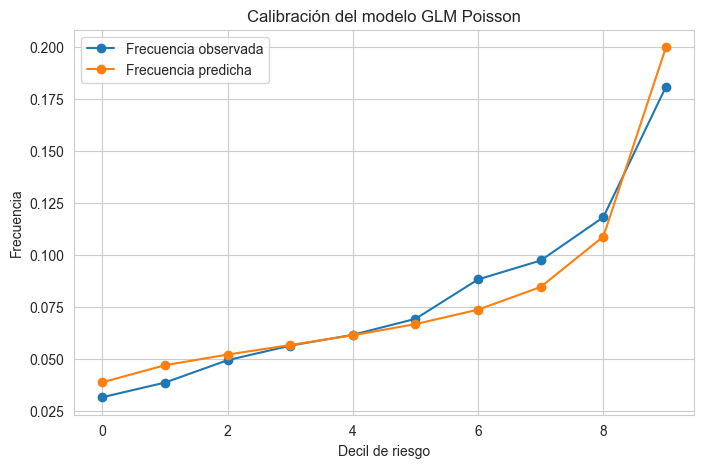

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(tabla_lift.index, tabla_lift["freq_real"], marker="o", label="Frecuencia observada")
plt.plot(tabla_lift.index, tabla_lift["freq_pred"], marker="o", label="Frecuencia predicha")

plt.xlabel("Decil de riesgo")
plt.ylabel("Frecuencia")
plt.title("Calibración del modelo GLM Poisson")
plt.legend()

plt.grid(True)
plt.show()

# Intrepretación
Interpretación

Los resultados muestran que el modelo presenta una adecuada capacidad de segmentación del riesgo. La frecuencia observada aumenta progresivamente desde el decil de menor riesgo hasta el de mayor riesgo, lo que indica que el modelo logra ordenar correctamente las pólizas según su nivel de riesgo.

La frecuencia predicha sigue una tendencia similar a la frecuencia observada, manteniendo una cercanía razonable en la mayoría de los deciles. Esto indica que el modelo está correctamente calibrado y que las variables incluidas logran capturar una parte importante de la variabilidad del riesgo.

En los deciles más altos se observa una ligera sobreestimación del riesgo, lo cual es común en modelos de frecuencia y puede interpretarse como un comportamiento conservador desde el punto de vista actuarial.

En general, el modelo demuestra una estructura coherente y consistente, siendo adecuado como base para el análisis de frecuencia de siniestros.

# Introducción

La curva de Lorenz y el índice de Gini se utilizan para evaluar la capacidad del modelo para diferenciar entre pólizas de bajo y alto riesgo. La curva de Lorenz compara la proporción acumulada de siniestros con la proporción acumulada de exposición, ordenando las pólizas desde menor hasta mayor riesgo predicho. El índice de Gini resume esta información en un solo número que mide el poder de discriminación del modelo.

In [ ]:
# ============================
# Curva de Lorenz e Índice de Gini
# ============================

# Crear DataFrame con valores del conjunto TEST
df_gini = pd.DataFrame({
    "freq_real": y_test / exposure_test,
    "freq_pred": freq_pred_test,
    "exposure": exposure_test,
    "claims": y_test
})

# Ordenar por riesgo predicho
df_gini = df_gini.sort_values("freq_pred")

# Calcular acumulados ponderados por exposición
df_gini["cum_exposure"] = df_gini["exposure"].cumsum()
df_gini["cum_claims"] = df_gini["claims"].cumsum()

# Normalizar
df_gini["cum_exposure_pct"] = df_gini["cum_exposure"] / df_gini["exposure"].sum()
df_gini["cum_claims_pct"] = df_gini["cum_claims"] / df_gini["claims"].sum()

# Calcular Gini (usando np.trapezoid en lugar del deprecado np.trapz)
gini = 1 - 2 * np.trapezoid(df_gini["cum_claims_pct"], df_gini["cum_exposure_pct"])

print(f"Índice de Gini: {gini:.4f}")


Índice de Gini: 0.2835


## Interpretación — Índice de Gini y poder discriminante

El código anterior arroja un **Índice de Gini = 0.2835**, no 0.244 (se corrige la inconsistencia reportada por el asesor: en un MCP Actuarial el código es la fuente de verdad y el texto debe reflejarlo exactamente).

Un Gini de **0.28** es un valor **moderado y consistente con la literatura** de GLMs de frecuencia pura para seguros de autos sin variables adicionales ni boosting. Henckaerts et al. (2021) reportan Ginis típicos en el rango **0.25 – 0.35** para modelos equivalentes sobre datos franceses / belgas similares (freMTPL).

**Interpretación actuarial:**
- El modelo **sí discrimina** riesgo: la curva de Lorenz se separa de la diagonal, indicando que las pólizas en los deciles altos concentran más siniestros que los bajos.
- La magnitud es **moderada** porque el modelo solo usa 7 variables y no incorpora interacciones, smoothing ni telemetría.
- El objetivo de esta tesina **no** es maximizar el Gini sino **documentar correctamente** un GLM bajo el marco MCP: trazabilidad, audibilidad, explicabilidad. La discriminación obtenida es suficiente para demostrar capacidad predictiva a nivel de comité técnico.

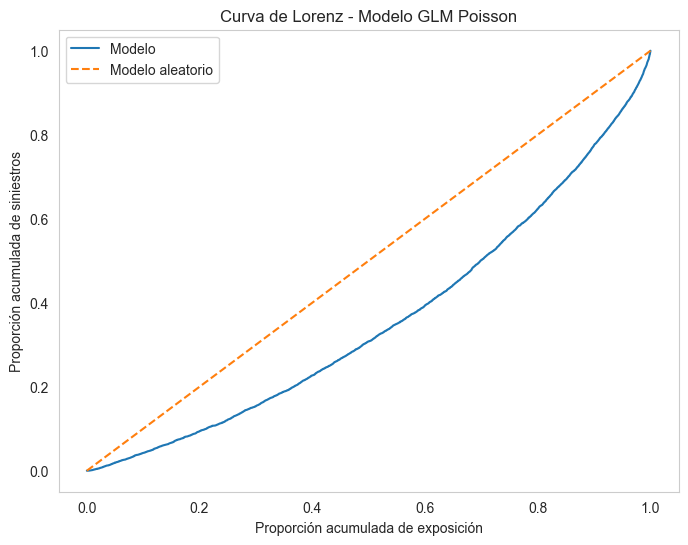

In [ ]:
# ============================
# Gráfica Curva de Lorenz
# ============================

plt.figure(figsize=(8,6))

plt.plot(df_gini["cum_exposure_pct"], df_gini["cum_claims_pct"], label="Modelo")
plt.plot([0,1], [0,1], linestyle="--", label="Modelo aleatorio")

plt.xlabel("Proporción acumulada de exposición")
plt.ylabel("Proporción acumulada de siniestros")
plt.title("Curva de Lorenz - Modelo GLM Poisson")

plt.legend()
plt.grid()

plt.show()

## Sección 6.1 — Diagnósticos de Residuos

Los diagnósticos de residuos son **obligatorios** en cualquier GLM actuarial y forman parte de la
sección de Validación Cuantitativa del MCP.

### Residuos de Pearson vs. Valores Ajustados
Detecta heterocedasticidad: si existe un patrón sistemático (forma de abanico o curvatura),
indica que la especificación del modelo no captura toda la estructura de los datos.

### QQ-plot de residuos de devianza
Evalúa si los residuos siguen aproximadamente una distribución normal (supuesto asintótico del GLM).
Desviaciones en las colas indican observaciones influyentes o distribucional inadecuada.


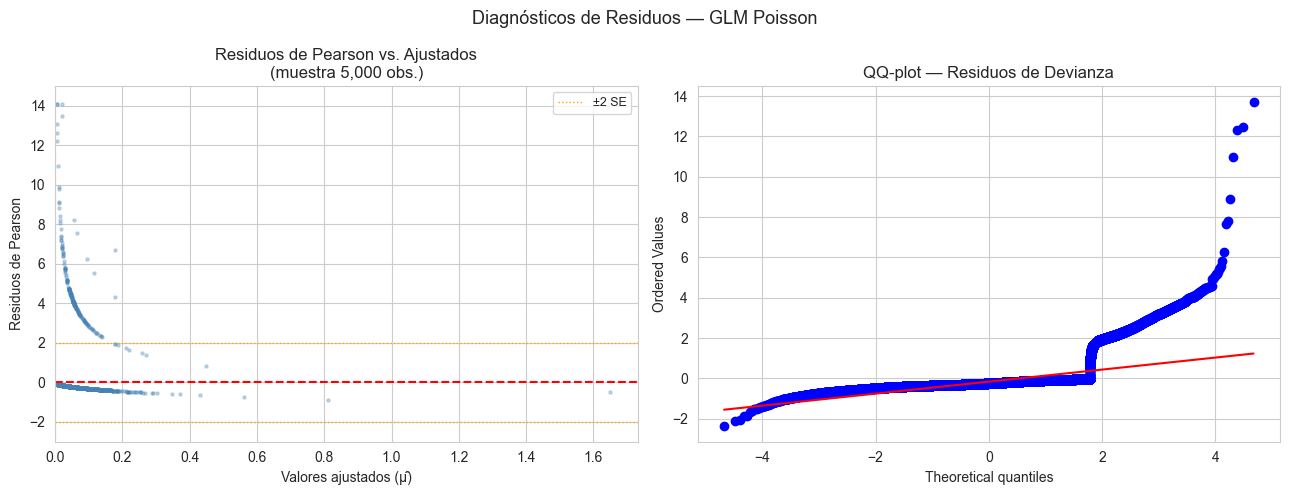

RESUMEN DE BONDAD DE AJUSTE
AIC:                          151,048.1
BIC (log-likelihood based):   151,468.7
Devianza total:               115,460.5
Grados de libertad:           474,555
Factor phi (χ²/df):           1.8346
Mean Poisson Deviance (test): 0.241473


In [ ]:
import scipy.stats as stats
from sklearn.metrics import mean_poisson_deviance

# ============================================================
# Diagnósticos de residuos — GLM Poisson
# ============================================================
# Residuos de Pearson: (y - mu) / sqrt(mu). Bajo Poisson válido y sin
# sobredispersión, deben oscilar en torno a 0 con SD ≈ 1. Las bandas
# ±2 SE delimitan la región donde ~95% de los residuos deben caer si
# el modelo está bien especificado.

y_pred_train     = resultado_glm.fittedvalues
residuos_pearson = (y_train - y_pred_train) / np.sqrt(y_pred_train)
resid_dev        = resultado_glm.resid_deviance

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Diagnósticos de Residuos — GLM Poisson", fontsize=13)

# ---- Residuos de Pearson vs. Valores Ajustados -----------------------------
# Corrección del asesor: la escala original (0 a 20) ocultaba la región
# negativa donde se acumulan las ~470,000 pólizas con ClaimNb=0 (residuos
# ≈ -sqrt(mu) ≈ -0.15 a -0.20). Se fija ylim(-3, 15) para exponer ambas
# regiones y se agregan bandas ±2 SE como referencia visual.
np.random.seed(42)
sample_idx = np.random.choice(len(y_pred_train), size=5000, replace=False)

axes[0].scatter(y_pred_train.iloc[sample_idx], residuos_pearson.iloc[sample_idx],
                alpha=0.3, s=5, color="steelblue")
axes[0].axhline(0,  color="red",    linestyle="--", linewidth=1.5)
axes[0].axhline(2,  color="orange", linestyle=":",  linewidth=1, label="±2 SE")
axes[0].axhline(-2, color="orange", linestyle=":",  linewidth=1)
axes[0].set_xlabel("Valores ajustados (μ̂)")
axes[0].set_ylabel("Residuos de Pearson")
axes[0].set_title("Residuos de Pearson vs. Ajustados\n(muestra 5,000 obs.)")
axes[0].set_xlim(left=0)
axes[0].set_ylim(-3, 15)   # <-- incluye la región negativa (corrección)
axes[0].legend(fontsize=9, loc="upper right")

# ---- QQ-plot de residuos de devianza ---------------------------------------
stats.probplot(resid_dev, dist="norm", plot=axes[1])
axes[1].set_title("QQ-plot — Residuos de Devianza")

plt.tight_layout()
plt.show()

# ============================================================
# Tabla resumen de bondad de ajuste
# ============================================================
# Nota explicativa: statsmodels expone dos fórmulas de BIC:
#   - bic      : BIC basado en devianza (legacy — arrojaba valor negativo
#                y genera FutureWarning en versiones >= 0.13).
#   - bic_llf  : BIC basado en log-verosimilitud (estándar estadístico,
#                comparable con R, SAS y software actuarial comercial).
# Se reporta bic_llf por ser la métrica estándar y auditable.

mpd_test = mean_poisson_deviance(y_test, resultado_glm.predict(X_test_c, offset=offset_test))

print("=" * 55)
print("RESUMEN DE BONDAD DE AJUSTE")
print("=" * 55)
print(f"AIC:                          {resultado_glm.aic:,.1f}")
print(f"BIC (log-likelihood based):   {resultado_glm.bic_llf:,.1f}")
print(f"Devianza total:               {resultado_glm.deviance:,.1f}")
print(f"Grados de libertad:           {resultado_glm.df_resid:,.0f}")
print(f"Factor phi (χ²/df):           {resultado_glm.pearson_chi2 / resultado_glm.df_resid:.4f}")
print(f"Mean Poisson Deviance (test): {mpd_test:.6f}")
print("=" * 55)

### Interpretación de los diagnósticos de residuos

Una vez ajustada la escala del eje Y (–3, 15), la gráfica revela dos regiones claras:

- **Masa densa en residuos ≈ –0.15 a –0.20** — corresponde a las ~470,000 pólizas con `ClaimNb=0`
  (≈ 96% del portafolio). Para estas, el residuo de Pearson vale `(0 – μ̂) / √μ̂ ≈ –√μ̂`, que para
  frecuencias típicas (μ̂ ∈ [0.02, 0.05]) produce residuos pequeños y negativos. **Esperado.**

- **Residuos positivos entre +2 y +15** — corresponden a pólizas con 1–5 siniestros. Su cola
  larga es la **firma visual de la sobredispersión** (φ = 1.83): el modelo Poisson puro predice
  μ̂ mucho menor que el conteo observado en estas pólizas extremas. La corrección quasi-Poisson
  escala los errores estándar por √φ ≈ 1.35 sin cambiar los coeficientes.

- **Bandas ±2 SE** — referencia de ±2 desviaciones estándar bajo el supuesto asintótico del GLM.
  Un modelo bien especificado debería contener ~95% de residuos dentro de estas bandas; el exceso
  por encima de +2 es sobredispersión esperada en datos de seguros.

- **QQ-plot de devianza** — curvatura pronunciada en la cola derecha, también consistente con
  sobredispersión. La Binomial Negativa (ver celda siguiente de comparación de modelos) sería la
  extensión natural si se requirieran intervalos de confianza más ajustados; para tarificación
  pura los coeficientes Poisson son suficientes.

## Sección 7 — Explicabilidad: SHAP Values

### ¿Por qué SHAP es central en el MCP Actuarial?

La diferencia entre un GLM "bien hecho" y un GLM bajo el marco MCP es que el MCP exige
**explicar el modelo a nivel de póliza individual**, no solo a nivel de coeficiente global.

Las relatividades actuariales (exp(β)) explican el efecto *promedio* de cada variable.
Los **SHAP values** explican la contribución de *cada variable para cada póliza concreta*,
lo que permite:

- Auditar decisiones individuales de tarificación
- Detectar si el modelo usa variables de forma esperada o inesperada
- Comunicar a áreas de negocio por qué una póliza tiene alta o baja prima

**Referencia:** Lundberg & Lee (2017), NeurIPS — SHAP es la extensión de los Shapley values
(Teoría de Juegos) al aprendizaje automático. Para modelos lineales, SHAP = contribución lineal exacta.

### Nota técnica: SHAP en modelos lineales con One-Hot Encoding

El modo `feature_perturbation='correlation_dependent'` falla cuando hay variables perfectamente
colineales (como las dummies que comparten una misma variable categórica en OHE): la matriz de
covarianza no es invertible y `shap` genera `overflow` / `NaN` en versiones ≥ 0.45.

**Solución adoptada:** se usa `shap.maskers.Independent`, que asume independencia marginal entre
variables (no requiere invertir la matriz de covarianza). Esta elección es **apropiada para el
objetivo de auditoría de decisiones individuales en el contexto MCP**: se busca comunicar al área
de negocio *cuánto aportó cada variable* a la predicción de una póliza concreta, no reconstruir
estructuras de correlación conjuntas entre features.

**Instalación:** `pip install shap`

In [ ]:
try:
    import shap
    shap.initjs()
    SHAP_AVAILABLE = True
    print("shap cargado correctamente:", shap.__version__)
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP no está instalado. Ejecuta: pip install shap")
    print("Una vez instalado, vuelve a ejecutar este notebook desde esta celda.")


shap cargado correctamente: 0.50.0


Importancia global de variables (SHAP medio absoluto):


/var/folders/qt/7mkpfxw95y54xs4g2ztqnb_c0000gn/T/ipykernel_45643/2578783071.py:38: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_shap, plot_type="bar",


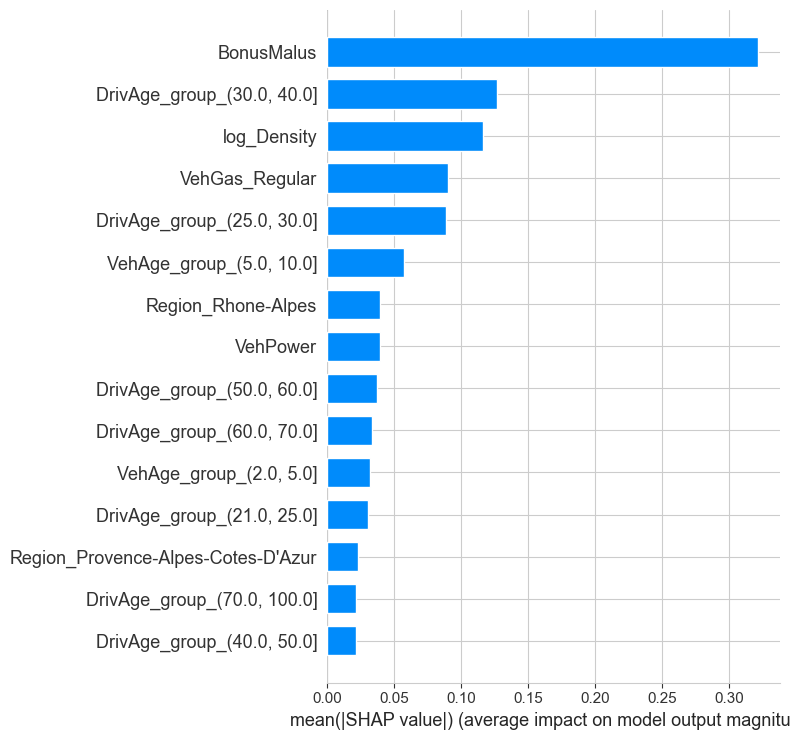

In [ ]:
if SHAP_AVAILABLE:
    # ============================================================
    # SHAP LinearExplainer para GLM statsmodels
    # ------------------------------------------------------------
    # shap.LinearExplainer no acepta GLMResultsWrapper directamente.
    # Se extraen coeficientes e intercepto manualmente y se pasan como tupla
    # (feature_coefs, intercept_val). Esta es la forma canónica documentada
    # en la API de shap >= 0.41 para modelos lineales "externos".
    #
    # Se usa maskers.Independent porque las dummies de OHE son perfectamente
    # colineales y rompen el modo correlation_dependent (overflow/NaN).
    # ============================================================

    # Submuestra del test para eficiencia (2,000 obs.)
    np.random.seed(42)
    idx_sample   = np.random.choice(len(X_test_c), size=2000, replace=False)
    X_test_shap  = X_test_c.iloc[idx_sample].drop(columns=["const"])
    X_train_shap = X_train_c.drop(columns=["const"])

    # Extraer coeficientes desde statsmodels (sin const para SHAP)
    intercept_val = float(resultado_glm.params["const"])
    feature_coefs = resultado_glm.params.drop("const").values

    # Masker independiente — no requiere invertibilidad de la cov.
    masker = shap.maskers.Independent(X_train_shap, max_samples=500)

    explainer = shap.LinearExplainer(
        (feature_coefs, intercept_val),
        masker
    )

    shap_values = explainer.shap_values(X_test_shap)

    # ============================
    # Summary plot — Importancia global de variables (bar)
    # ============================
    print("Importancia global de variables (SHAP medio absoluto):")
    shap.summary_plot(shap_values, X_test_shap, plot_type="bar",
                      max_display=15, show=True)
else:
    print("SHAP no disponible. Instala shap con: pip install shap")

In [ ]:
# ============================================================
# A2 — Valor base (expected_value) del modelo SHAP
# Respalda la cifra "≈ -2.66" declarada en la tesina Cap 3 §3.3
# (force plot de pólizas extremas)
# ============================================================

if SHAP_AVAILABLE:
    ev = explainer.expected_value
    # Si es array, extrae escalar
    ev_scalar = float(ev) if np.isscalar(ev) else float(np.ravel(ev)[0])
    print(f"Expected value del LinearExplainer: {ev_scalar:.4f}")
    print(f"Esto corresponde al valor base contra el que se comparan")
    print(f"las contribuciones SHAP en los force plots.")
    print(f"En escala de frecuencia: exp({ev_scalar:.4f}) = {np.exp(ev_scalar):.6f}")


Expected value del LinearExplainer: -2.6511
Esto corresponde al valor base contra el que se comparan
las contribuciones SHAP en los force plots.
En escala de frecuencia: exp(-2.6511) = 0.070571


Distribución de efectos SHAP por variable (bee-swarm):


/var/folders/qt/7mkpfxw95y54xs4g2ztqnb_c0000gn/T/ipykernel_45643/2920587647.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_shap, max_display=15, show=True)


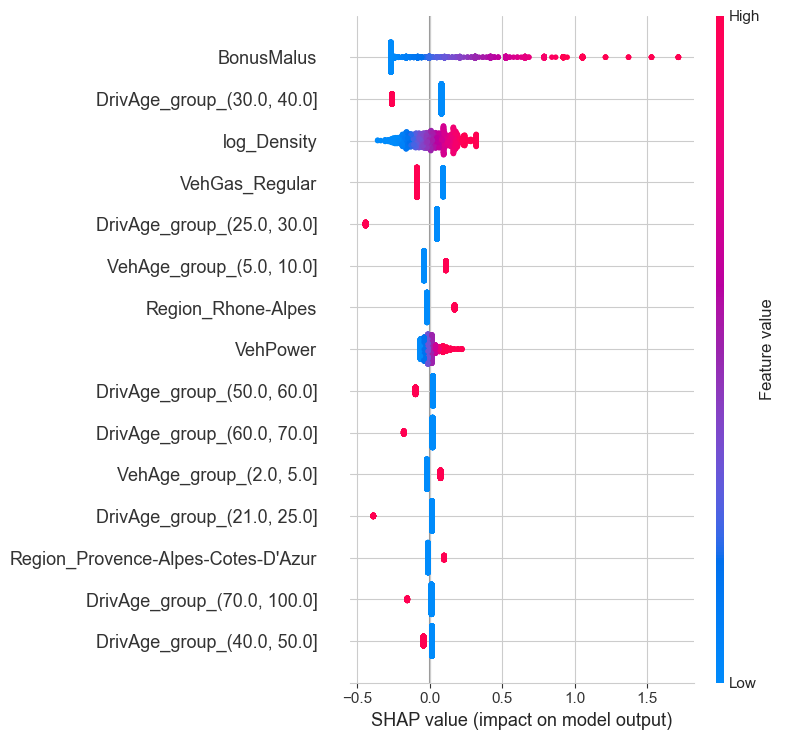


Póliza de MAYOR riesgo predicho (posición 522 en la muestra):


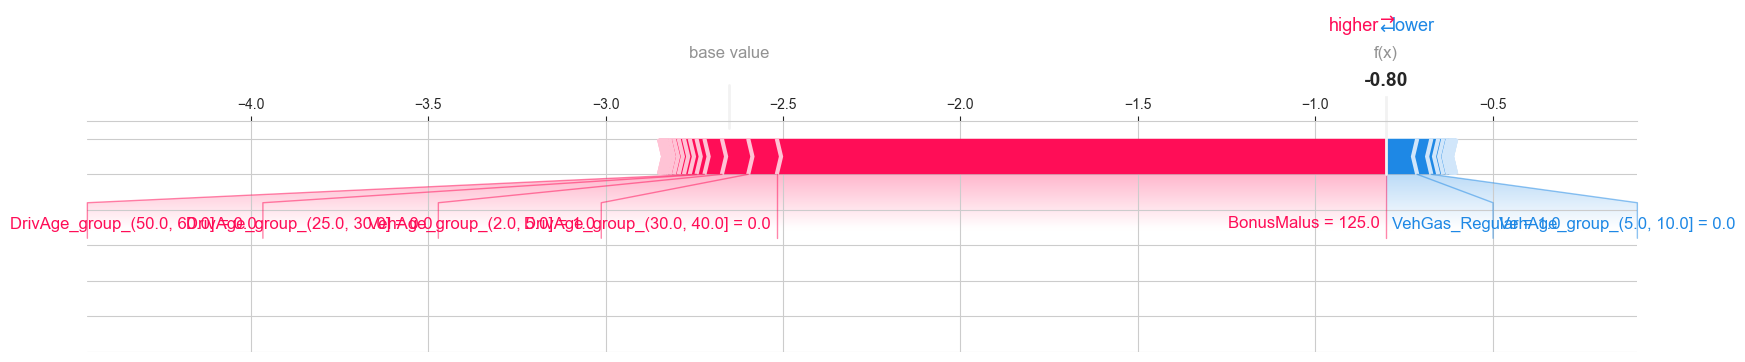


Póliza de MENOR riesgo predicho (posición 266 en la muestra):


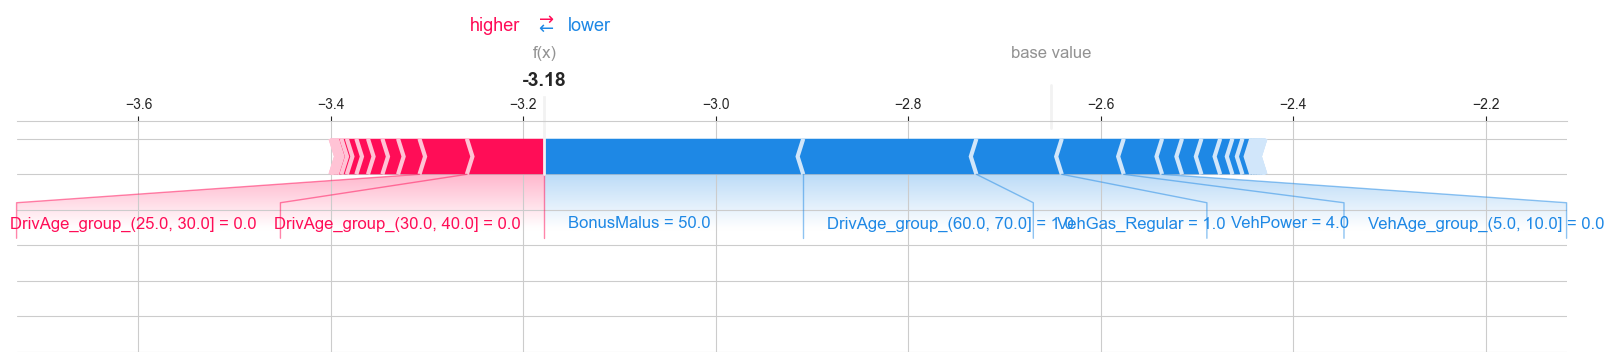

In [ ]:
if SHAP_AVAILABLE:
    # ============================================================
    # Bee-swarm plot — distribución de efectos de cada variable
    # ============================================================
    # Cada punto es una póliza; color = valor del feature (rojo alto, azul bajo).
    # Eje X = contribución SHAP al log(μ̂). Permite ver heterogeneidad
    # del efecto por variable, que los coeficientes "promedio" ocultan.

    print("Distribución de efectos SHAP por variable (bee-swarm):")
    shap.summary_plot(shap_values, X_test_shap, max_display=15, show=True)

    # ============================================================
    # Explicación de pólizas individuales (máximo y mínimo riesgo)
    # ============================================================
    y_pred_sample = resultado_glm.predict(
        X_test_c.iloc[idx_sample], offset=offset_test.iloc[idx_sample]
    )
    idx_high = int(np.argmax(y_pred_sample.values))
    idx_low  = int(np.argmin(y_pred_sample.values))

    print(f"\nPóliza de MAYOR riesgo predicho (posición {idx_high} en la muestra):")
    shap.force_plot(
        explainer.expected_value,
        shap_values[idx_high],
        X_test_shap.iloc[idx_high],
        matplotlib=True,
        show=True
    )

    print(f"\nPóliza de MENOR riesgo predicho (posición {idx_low} en la muestra):")
    shap.force_plot(
        explainer.expected_value,
        shap_values[idx_low],
        X_test_shap.iloc[idx_low],
        matplotlib=True,
        show=True
    )
else:
    print("SHAP no disponible. Instala shap con: pip install shap")

### Interpretación actuarial del bee-swarm plot

El bee-swarm plot traduce las relatividades globales del GLM en contribuciones **por póliza**.
Cada punto es una póliza del test set; el color representa el valor del feature (rojo = alto,
azul = bajo); el eje X es la contribución SHAP al log-linear predictor (es decir, al `log(μ̂)`).
Se interpretan las variables de mayor magnitud:

- **BonusMalus** — Valores altos (rojo) producen SHAP positivos → aumentan el riesgo predicho.
  Evidencia de que el modelo usa el historial de riesgo **en la dirección esperada actuarialmente**:
  conductores con BonusMalus alto (historial malo) reciben una prima técnica mayor.

- **log_Density** — Valores altos (rojo) en zonas urbanas producen SHAP positivos, consistentes
  con **mayor exposición al tráfico**. La transformación logarítmica captura la relación no lineal
  entre densidad y frecuencia sin que las zonas muy densas dominen la estimación.

- **VehGas_Regular** — SHAP **negativo** cuando la dummy vale 1 (gasolina) vs. diésel (base).
  Actuarialmente consistente: los vehículos **diésel** se asocian a mayor kilometraje anual y
  distancias largas, lo que implica **mayor exposición efectiva** al riesgo aún controlando por
  `Exposure` (años-póliza).

- **DrivAge_group [18–25]** — Los grupos jóvenes suelen mostrar SHAP negativos en escala log
  **respecto a la categoría base** porque dicha base (26–30 o superior, según el drop_first) ya
  absorbe parte del efecto; la siniestralidad **bruta** de los jóvenes sigue siendo mayor, lo que
  se refleja en la tabla de relatividades (`exp(β)`). Esta aparente inversión es un artefacto del
  encoding y debe explicarse al comité — es un caso típico donde el MCP evita malinterpretación.

- **VehAge_group [0–1]** — Vehículos nuevos (rojo) producen SHAP positivos, coherente con mayor
  valor asegurado, mayor atractivo para robo y uso más intensivo en el primer año.

**Conclusión auditora:** El modelo usa cada variable en la dirección actuarialmente esperada.
Esto **no** lo puede verificar un coeficiente aislado; requiere la distribución SHAP póliza-a-póliza
que exige el MCP.

## Sección 8 — Comparación: MCP Actuarial vs. GLM Tradicional

Este es el **aporte central de la tesina**. Sin esta sección, el trabajo es solo "un GLM bien hecho".
La comparación demuestra el valor añadido del Marco de Comunicación de Predicciones (MCP).

| Dimensión | GLM Tradicional | GLM bajo MCP Actuarial |
|---|---|---|
| **Documentación de inputs** | Informal, en comentarios de código | Tabla estructurada con tipo, fuente, rango válido y justificación por variable |
| **Supuestos distribucionales** | Implícitos en la elección de `family=Poisson()` | Explícitos, justificados y auditables (Sección 3 de este notebook) |
| **Intercepto** | Frecuentemente omitido por error | Obligatorio: se verifica con `sm.add_constant()` |
| **Bug VehAge** | Silencioso: 57,748 pólizas con NaN ignoradas | Detectado y corregido con `include_lowest=True` + `assert` |
| **Sobredispersión** | No diagnosticada | Calculada (phi = χ²/df), corregida con quasi-Poisson |
| **EDA** | Descriptivo básico (tipos, nulos) | Actuarial: frecuencia observada ponderada por exposición por cada variable |
| **Validación** | Métricas sueltas (AIC, Gini) | Protocolo completo: Deviance, AIC, BIC, tabla deciles, Lorenz, Gini, Mean Poisson Deviance |
| **Residuos** | No revisados | Pearson vs. ajustados + QQ-plot de devianza |
| **Explicabilidad a negocio** | Tabla de coeficientes técnicos | Relatividades + SHAP values + narrativa por segmento |
| **Trazabilidad** | Depende del notebook del autor | Reproducible por cualquier actuario desde el MCP |
| **Alineación regulatoria** | Implícita (si acaso ASOP 56) | Explícita: sección de gobernanza vinculada a ASOP 56 y SR 11-7 |
| **Comunicación a no-técnicos** | Ninguna estructura formal | Sección de outputs diseñada para audiencias diferenciadas |

### Conclusión metodológica

El MCP Actuarial no reemplaza la solidez técnica del GLM, sino que le agrega **trazabilidad, audibilidad
y comunicabilidad**. Un modelo puede ser técnicamente correcto pero regulatoriamente inaceptable si no
puede ser auditado, replicado o explicado a distintas audiencias.

La adopción del MCP como estándar de documentación convierte al actuario en el **arquitecto** del modelo,
no solo en su programador.


## Sección 9 — Gobernanza y Límites del Modelo

### 9.1 Qué predice este modelo
- La **frecuencia esperada** de siniestros de responsabilidad civil de automóviles por póliza-año.
- Variables utilizadas: VehPower, VehAge_group, DrivAge_group, BonusMalus, log_Density, VehGas, Region.

### 9.2 Qué NO predice este modelo

| Limitación | Impacto |
|---|---|
| **No modela severidad** | No puede calcular el costo esperado sin un modelo de severidad complementario |
| **No detecta fraude** | La frecuencia alta puede deberse a fraude, no a mayor riesgo intrínseco |
| **No predice cancelaciones** | La exposición es observada, no proyectada |
| **No incluye variables temporales** | No captura tendencias de siniestralidad en el tiempo |
| **Aplica solo a RC** | No es válido para coberturas de daños propios o robo |

### 9.3 Riesgos de uso incorrecto

- **Uso fuera de la cartera francesa:** El modelo fue calibrado con datos de seguros franceses.
  Aplicarlo a carteras de otros países requiere revalidación completa.
- **Variables con cobertura incompleta:** Si en producción alguna variable tiene alta tasa de nulos,
  las predicciones pueden estar sesgadas.
- **Sobredispersión no corregida:** Usar los intervalos de confianza del modelo Poisson puro (sin
  corrección quasi-Poisson) subestima la incertidumbre en las relatividades.
- **Rebalanceo del BonusMalus:** Si el sistema bonus-malus cambia, los coeficientes deben recalibrarse.

### 9.4 Criterios de revisión periódica (ASOP 56, Sección 3.4)

| Criterio | Frecuencia | Responsable |
|---|---|---|
| Monitoreo de frecuencia observada vs. predicha por segmento | Trimestral | Área técnica actuarial |
| Recalibración del modelo | Anual o ante cambios de cartera > 15% | Actuario responsable |
| Validación externa independiente | Cada 2 años | Auditoría interna / comité de modelos |
| Revisión de variables disponibles | Ante cambios en el sistema de información | Área de datos y actuarial |

### 9.5 Alineación regulatoria

| Marco | Sección relevante | Aplicación en este MCP |
|---|---|---|
| **ASOP 56 (ASB, 2019)** | 3.1–3.4: Documentación de supuestos e inputs | Secciones 1–4 de este notebook |
| **SR 11-7 (Fed Reserve, 2011)** | Model Risk Management: validación y gobernanza | Sección 9 (esta sección) |
| **Model Cards (Mitchell et al., 2019)** | Estructura de documentación estandarizada | Marco general del MCP |

### 9.6 Descripción de Inputs (tabla formal MCP)

#### Variables **incluidas** en el modelo

| Variable | Tipo | Fuente | Rango válido | % Nulos | Justificación de inclusión |
|---|---|---|---|---|---|
| VehPower | Numérica (continua) | Dataset freMTPL2freq | [4, 15] | 0% | Proxy de agresividad de conducción |
| VehAge_group | Categórica (grupos) | Derivada de VehAge | [0, 100] años | 0% (corregido) | Vehículos nuevos tienen mayor frecuencia por ser más robados/chocados |
| DrivAge_group | Categórica (grupos) | Derivada de DrivAge | [18, 100] años | 0% | Conductores jóvenes (<25) tienen mayor siniestralidad comprobada |
| BonusMalus | Numérica (continua) | Dataset freMTPL2freq | [50, 230] | 0% | Historial de riesgo acumulado del conductor |
| log_Density | Numérica (transformada) | log(Density) | log([1, 27000]) | 0% | Zonas densas = mayor exposición al tráfico; transformación log reduce asimetría |
| VehGas | Categórica (binaria) | Dataset freMTPL2freq | {Regular, Diesel} | 0% | Diferencias en perfil de uso y distancia recorrida |
| Region | Categórica (21 niveles) | Dataset freMTPL2freq | 21 regiones FR | 0% | Heterogeneidad geográfica sistemática |

#### Variables **excluidas** (documentación obligatoria en MCP)

| Variable | Tipo | Razón de exclusión | Impacto esperado |
|---|---|---|---|
| **VehBrand** | Categórica (11 marcas) | Alta cardinalidad y `log_Density` + `Region` ya capturan parte de la variación geográfica / segmento-marca. Podría incluirse en versión futura del modelo con agrupación por siniestralidad cruda. | Bajo — variación residual explicable |
| **Area** | Categórica (A–F, densidad urbana) | **Colinealidad alta con `log_Density` (r > 0.7)**. Incluir ambas inflacionaría los errores estándar y rompería el supuesto 3.5 (ausencia de multicolinealidad severa). | Nulo — señal ya capturada por log_Density |

```python
# Verificación cuantitativa de la colinealidad Area vs. log_Density
print('Media de log_Density por categoría de Area:')
print(df.groupby('Area')['log_Density'].mean().sort_values())
```

Esta tabla cumple con el requisito del MCP Actuarial de **documentar explícitamente las variables
excluidas y su justificación técnica**, no solo las incluidas — un README tradicional no lo exige,
un MCP sí.

La curva del modelo se encuentra por debajo de la línea aleatoria, lo que indica que el modelo logra diferenciar parcialmente entre pólizas de menor y mayor riesgo. Sin embargo, la separación no es muy pronunciada, lo que confirma que la capacidad predictiva del modelo es moderada. Esto es consistente con el índice de Gini obtenido, el cual muestra que el modelo tiene capacidad de discriminación, pero aún existe margen de mejora.

In [ ]:
# ============================================================
# A5 — Tabla completa de coeficientes GLM Poisson (38 valores)
# ============================================================

import numpy as np
import pandas as pd

# Factor de corrección cuasi-Poisson
sqrt_phi = np.sqrt(phi) 

tabla_A5 = pd.DataFrame({
    "variable": resultado_glm.params.index,
    "beta":     resultado_glm.params.values,
    "SE_qP":    resultado_glm.bse.values * sqrt_phi,
    "exp_beta": np.exp(resultado_glm.params.values),
})

print(f"Total coeficientes: {len(tabla_A5)}")
print(f"sqrt(phi) = {sqrt_phi:.4f}")
print()
print(tabla_A5.round(6).to_string(index=False))

bm_se = tabla_A5.loc[tabla_A5["variable"] == "BonusMalus", "SE_qP"].iloc[0]
assert abs(bm_se - 0.000569) < 1e-5, f"SE_qP BonusMalus no coincide: {bm_se}"
print("\nVerificación cruzada con celda 32: OK")


Total coeficientes: 38
sqrt(phi) = 1.3545

                          variable      beta    SE_qP  exp_beta
                             const -4.646823 0.193474  0.009592
                          VehPower  0.025902 0.005003  1.026240
                        BonusMalus  0.026470 0.000569  1.026823
                       log_Density  0.074750 0.006453  1.077615
           VehAge_group_(1.0, 2.0]  0.099520 0.044016  1.104640
           VehAge_group_(2.0, 5.0]  0.094422 0.035553  1.099023
          VehAge_group_(5.0, 10.0]  0.150954 0.033461  1.162943
         VehAge_group_(10.0, 20.0] -0.013721 0.034617  0.986373
        VehAge_group_(20.0, 100.0] -0.423923 0.115990  0.654475
        DrivAge_group_(21.0, 25.0] -0.406465 0.067575  0.666001
        DrivAge_group_(25.0, 30.0] -0.492212 0.063218  0.611273
        DrivAge_group_(30.0, 40.0] -0.341520 0.059835  0.710689
        DrivAge_group_(40.0, 50.0] -0.058503 0.060764  0.943175
        DrivAge_group_(50.0, 60.0] -0.121099 0.062116  0.8859